In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [25]:
df = pd.read_csv("retail_store_sales.csv")

Dataset Overview

In [26]:
print("Dataset shape:", df.shape)


Dataset shape: (12575, 11)


In [27]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [29]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


In [30]:
df.describe()


,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


Dropping rows where key numeric fields are missing

Data Cleaning & Preparation

In [31]:
df = df.dropna(subset=["Price Per Unit", "Quantity", "Total Spent"])

Filling missing 'Item' with 'Unknown'

In [32]:
df.loc[:, "Item"] = df["Item"].fillna("Unknown")

Filling missing 'Discount Applied' with 'Unknown'

In [33]:
df.loc[:, "Discount Applied"] = df["Discount Applied"].fillna("Unknown")

Converting inconsistent formats: date to datetime

In [34]:
df.loc[:, "Transaction Date"] = pd.to_datetime(df["Transaction Date"])

In [35]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

Проверка 

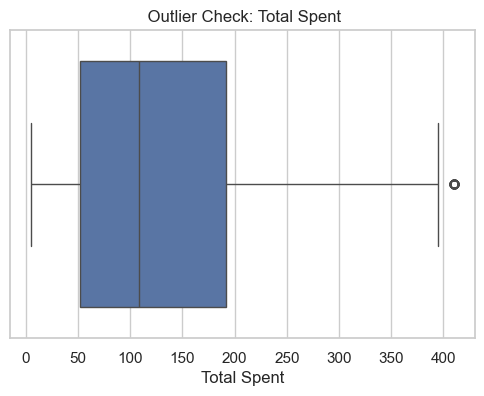

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Total Spent
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Total Spent'])
plt.title(" Outlier Check: Total Spent")
plt.show()

Outlier Detection: Total Spent Using IQR Method

In [38]:
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Normal range: {lower_bound:.2f} to {upper_bound:.2f}")

outliers = df[(df['Total Spent'] < lower_bound) | (df['Total Spent'] > upper_bound)]
print("Outliers detected:", outliers.shape[0])

df = df[(df['Total Spent'] >= lower_bound) & (df['Total Spent'] <= upper_bound)]
print("Data shape after removing outliers:", df.shape)


Normal range: -158.00 to 402.00
Outliers detected: 56
Data shape after removing outliers: (11306, 11)


In [39]:
df.duplicated().sum()

0

EDA 

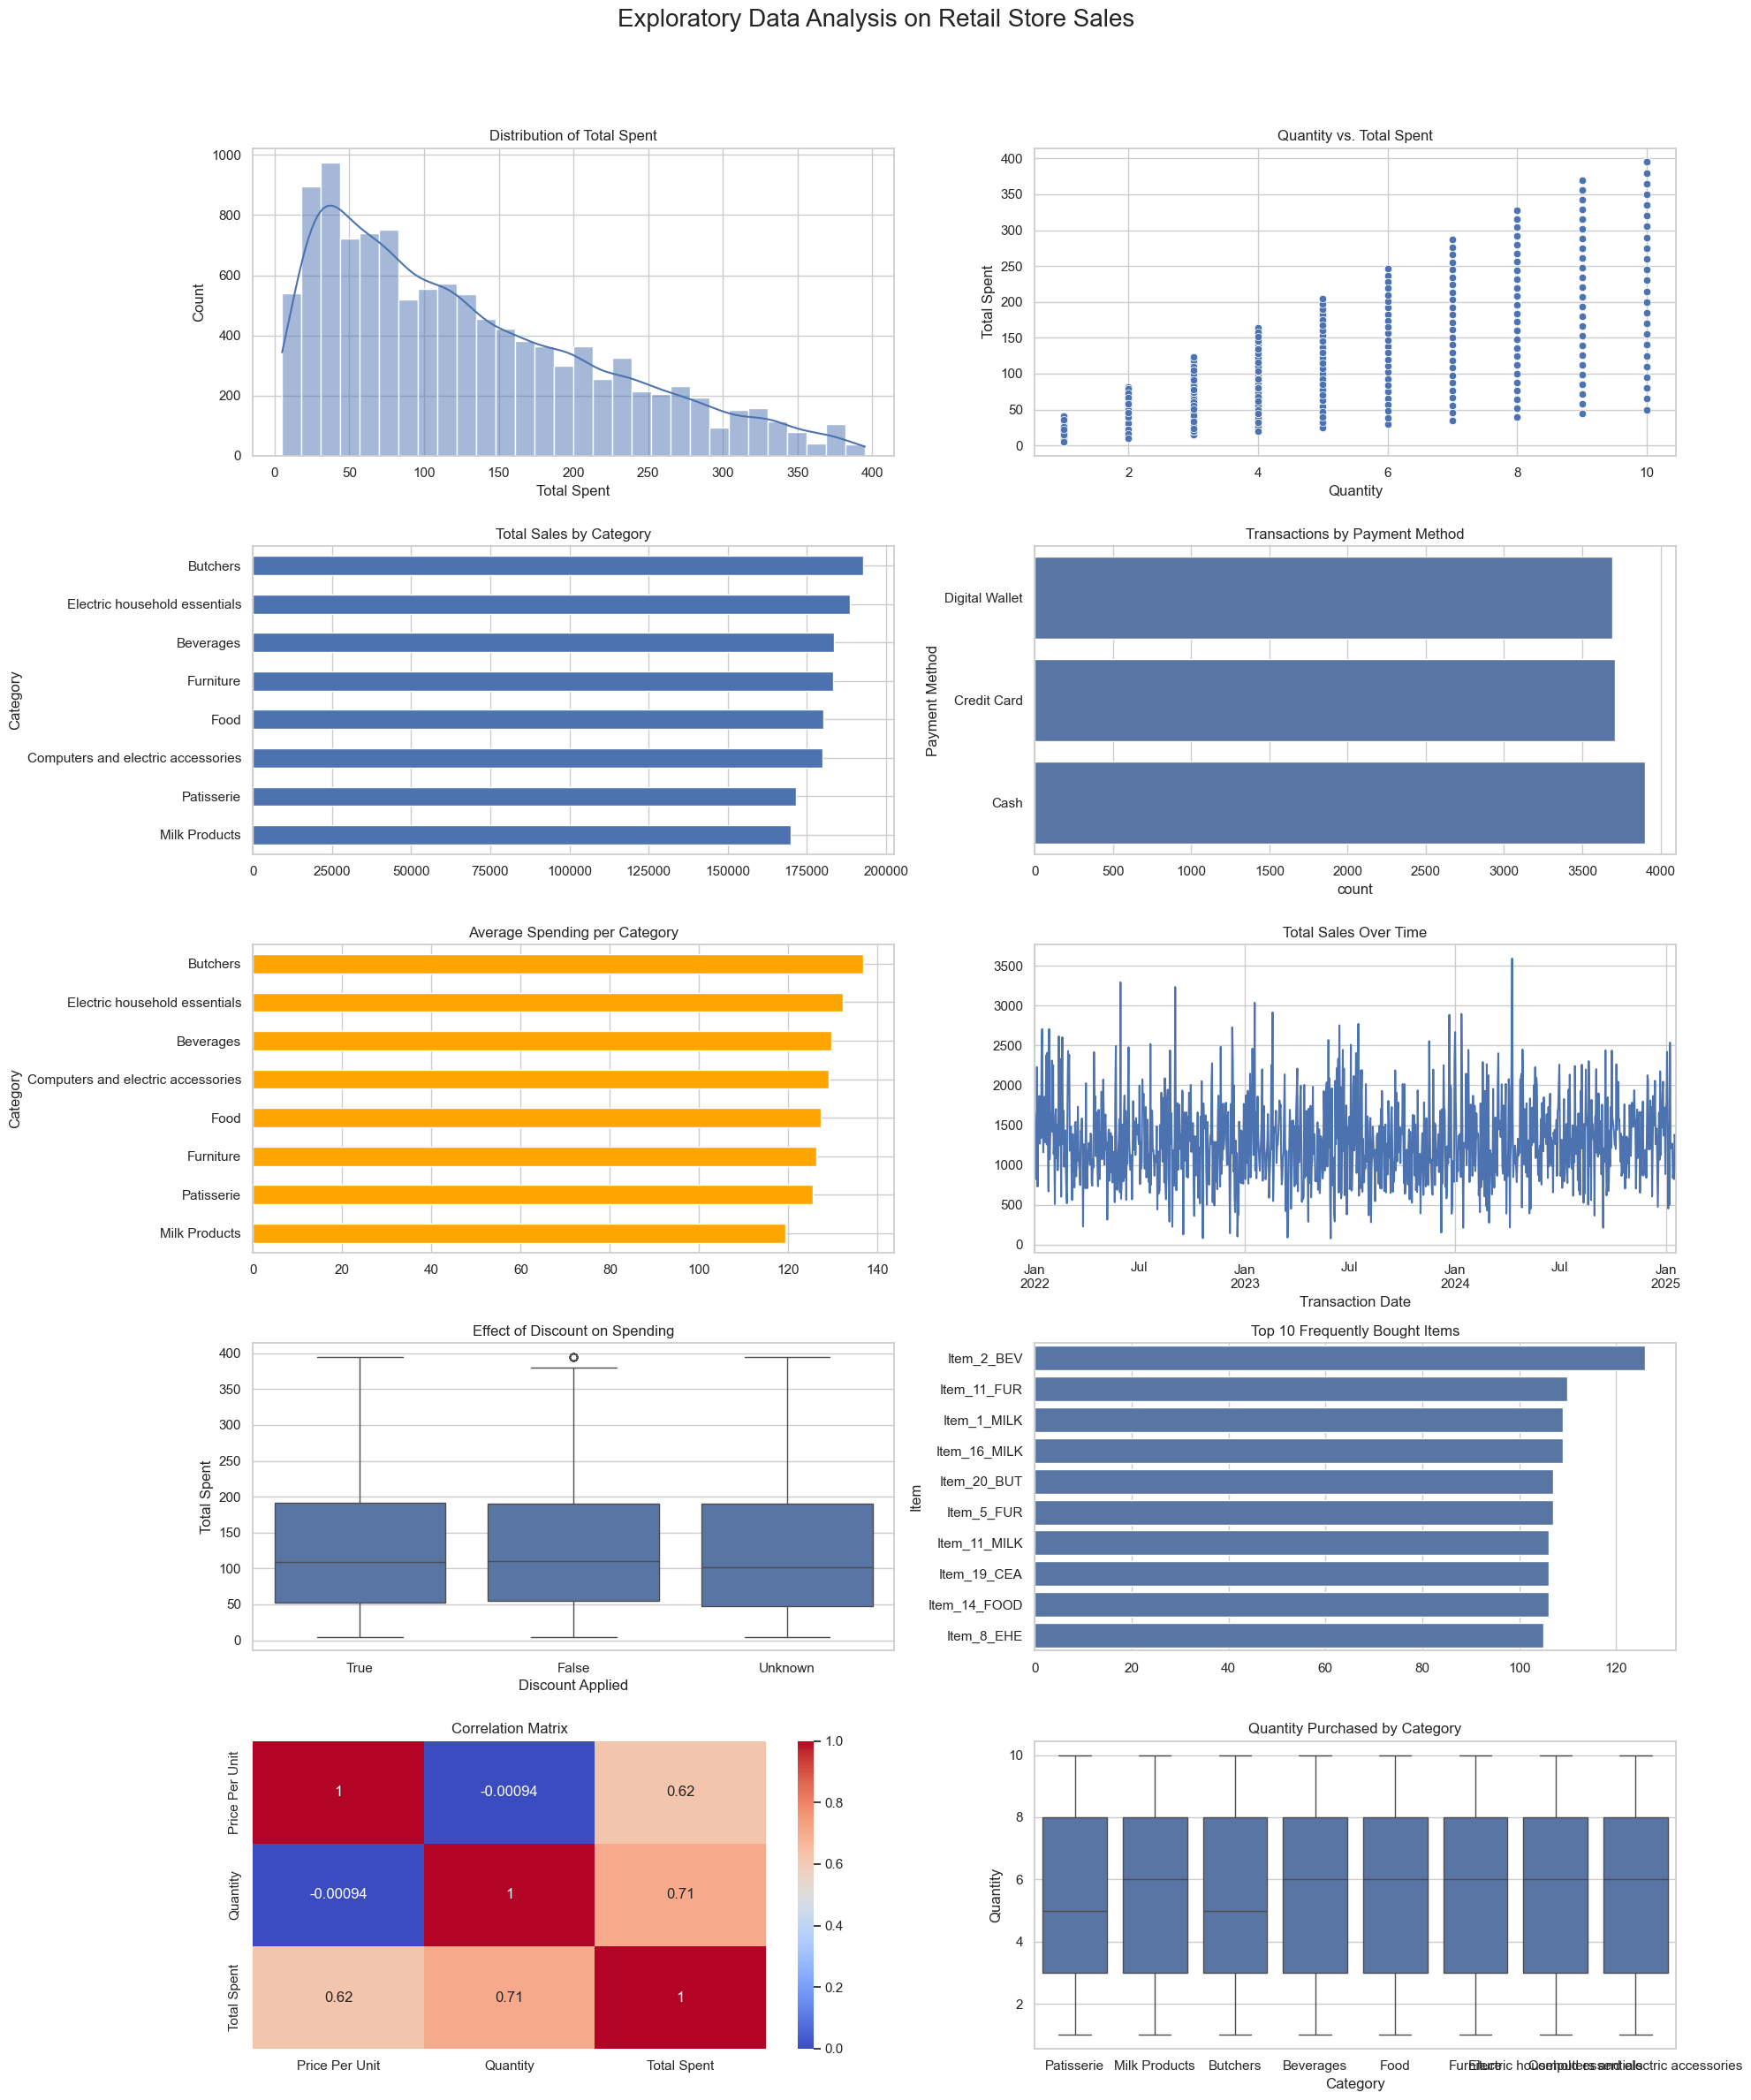

In [40]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(5, 2, figsize=(20, 25))
fig.suptitle("Exploratory Data Analysis on Retail Store Sales", fontsize=20)

sns.histplot(df["Total Spent"], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Total Spent")

sns.scatterplot(x="Quantity", y="Total Spent", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Quantity vs. Total Spent")

category_sales = df.groupby("Category")["Total Spent"].sum().sort_values()
category_sales.plot(kind="barh", ax=axes[1, 0])
axes[1, 0].set_title("Total Sales by Category")

sns.countplot(y="Payment Method", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Transactions by Payment Method")

avg_category = df.groupby("Category")["Total Spent"].mean().sort_values()
avg_category.plot(kind="barh", ax=axes[2, 0], color='orange')
axes[2, 0].set_title("Average Spending per Category")

sales_time = df.groupby("Transaction Date")["Total Spent"].sum()
sales_time.plot(ax=axes[2, 1])
axes[2, 1].set_title("Total Sales Over Time")

sns.boxplot(data=df, x="Discount Applied", y="Total Spent", ax=axes[3, 0])
axes[3, 0].set_title("Effect of Discount on Spending")

top_items = df["Item"].value_counts().head(10)
sns.barplot(x=top_items.values, y=top_items.index, ax=axes[3, 1])
axes[3, 1].set_title("Top 10 Frequently Bought Items")

corr = df[["Price Per Unit", "Quantity", "Total Spent"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[4, 0])
axes[4, 0].set_title("Correlation Matrix")

sns.boxplot(data=df, x="Category", y="Quantity", ax=axes[4, 1])
axes[4, 1].set_title("Quantity Purchased by Category")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Sales by Weekday

/var/folders/z8/pc06963d4072jjyq_y3w06980000gn/T/ipykernel_6414/1702638049.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekday_sales.index, y=weekday_sales.values, palette='Set2')


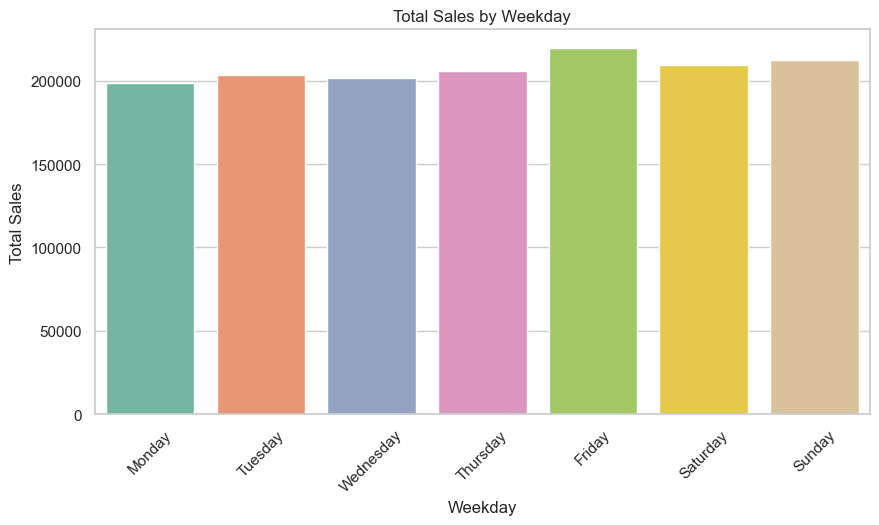

In [42]:
#Make sure the date is datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

#Extract weekday
df['Weekday'] = df['Transaction Date'].dt.day_name()

#Group and plot
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df.groupby('Weekday')['Total Spent'].sum().reindex(weekday_order)

plt.figure(figsize=(10,5))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values, palette='Set2')
plt.title('Total Sales by Weekday')
plt.ylabel('Total Sales')
plt.xlabel('Weekday')
plt.xticks(rotation=45)
plt.show()


Revenue by Location

Share of Repeat vs One-Time Buyers


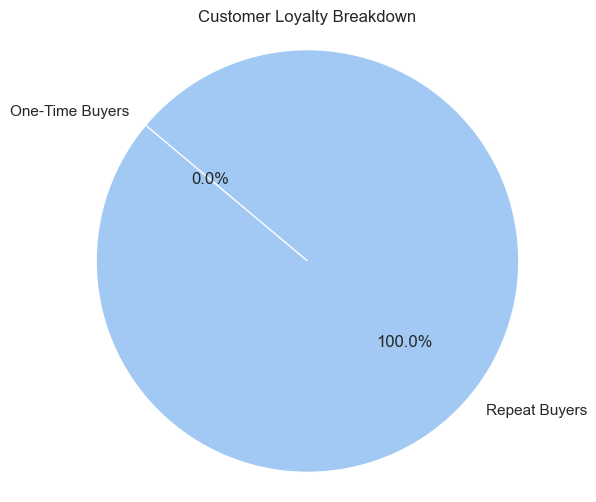

In [46]:
customer_orders = df['Customer ID'].value_counts()
repeat_customers = customer_orders[customer_orders > 1].count()
one_time_customers = customer_orders[customer_orders == 1].count()

labels = ['Repeat Buyers', 'One-Time Buyers']
sizes = [repeat_customers, one_time_customers]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Customer Loyalty Breakdown')
plt.axis('equal')
plt.show()

In the available dataset, 100% of customers are repeat buyers, indicating high loyalty or that first-time buyers are excluded from this data sample

Average Quantity per Order by Category

KPI и Business Metrics Calculation

Total Revenue, AOV, ARPU, Customer Value, LTV

In [61]:
print("Unique Customers:", df['Customer ID'].nunique())
print("Unique Transactions:", df['Transaction ID'].nunique())


Unique Customers: 25
Unique Transactions: 11306


In [62]:
# 1. Total Revenue
total_revenue = df['Total Spent'].sum()

# 2. Number of unique customers
num_customers = df['Customer ID'].nunique()

# 3. Total number of unique orders
total_orders = df['Transaction ID'].nunique()

# 4. Average Order Value (AOV)
aov = total_revenue / total_orders

# 5. Average Revenue Per User (ARPU)
arpu = total_revenue / num_customers

# 6. Purchase Frequency
purchase_frequency = total_orders / num_customers

# 7. Customer Value
customer_value = arpu * purchase_frequency

# 8. Lifetime Value (LTV) - assuming lifespan 12 months
lifespan_months = 12
ltv = customer_value * lifespan_months


In [63]:
# Building the summary table
metrics_df = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Average Order Value (AOV)',
        'Average Revenue Per User (ARPU)',
        'Purchase Frequency',
        'Customer Value',
        f'Lifetime Value (LTV) over {lifespan_months} months'
    ],
    'Value': [
        f"${total_revenue:,.2f}",
        f"${aov:.2f}",
        f"${arpu:.2f}",
        f"{purchase_frequency:.2f}",
        f"${customer_value:.2f}",
        f"${ltv:.2f}"
    ]
})

# Styling the output
from IPython.display import display, HTML

styled_metrics = metrics_df.style.set_table_styles([
    {'selector': 'thead th', 'props': [('background-color', '#f0f0f0'), ('color', 'black'), ('font-weight', 'bold')]},
    {'selector': 'tbody td', 'props': [('border', '1px solid #ccc')]}
]).set_properties(**{'text-align': 'left', 'padding': '5px'})

display(HTML('<h3>Financial KPIs</h3>'))
display(styled_metrics)


,Metric,Value
0,Total Revenue,"$1,450,038.50"
1,Average Order Value (AOV),$128.25
2,Average Revenue Per User (ARPU),$58001.54
3,Purchase Frequency,452.24
4,Customer Value,$26230616.45
5,Lifetime Value (LTV) over 12 months,$314767397.40


The dataset contains a relatively small number of unique customers (25) with a very high number of transactions (over 11,000).
This indicates a B2B or enterprise client structure, where each customer makes a large number of purchases, driving high ARPU, purchase frequency, and Customer Lifetime Value (LTV) figures

Basket Size — Average Quantity per Transaction

In [64]:
# Basket Size = Среднее количество товаров на одну транзакцию
basket_size = df.groupby('Transaction ID')['Quantity'].sum().mean()

print(f" Average Basket Size: {basket_size:.2f} items per order")


 Average Basket Size: 5.51 items per order


Average Days Between Purchases

In [65]:
# Make sure 'Transaction Date' is datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

# Sort transactions by customer and date
df_sorted = df.sort_values(by=['Customer ID', 'Transaction Date'])

# Calculate time difference between consecutive purchases
df_sorted['Prev Transaction Date'] = df_sorted.groupby('Customer ID')['Transaction Date'].shift(1)
df_sorted['Days Between Purchases'] = (df_sorted['Transaction Date'] - df_sorted['Prev Transaction Date']).dt.days

# Average days between purchases
avg_days_between = df_sorted['Days Between Purchases'].dropna().mean()

print(f"Average Days Between Purchases: {avg_days_between:.2f} days")


Average Days Between Purchases: 2.46 days


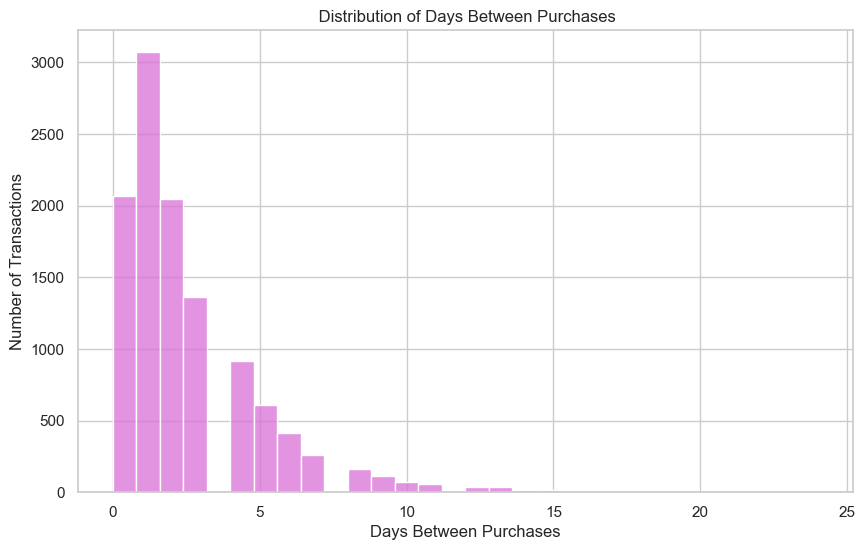

In [66]:
# Visualize distribution of days between purchases
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(df_sorted['Days Between Purchases'].dropna(), bins=30, color='orchid')
plt.title(' Distribution of Days Between Purchases')
plt.xlabel('Days Between Purchases')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()


Customers place relatively large orders (an average of 5.5 items per transaction) and return to purchase again approximately every 2.5 days, indicating a highly engaged and possibly B2B-focused customer base

Retention Rate и Churn Rate

In [67]:
customer_orders = df.groupby('Customer ID')['Transaction ID'].nunique()

# Retention: клиенты, которые покупали 2 раза или больше
retained_customers = customer_orders[customer_orders > 1].count()
total_customers = customer_orders.count()

retention_rate = retained_customers / total_customers * 100
churn_rate = 100 - retention_rate

print(f" Retention Rate: {retention_rate:.2f}%")
print(f" Churn Rate: {churn_rate:.2f}%")


 Retention Rate: 100.00%
 Churn Rate: 0.00%


Top Customer Analysis

/var/folders/z8/pc06963d4072jjyq_y3w06980000gn/T/ipykernel_6414/56281325.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette='muted')


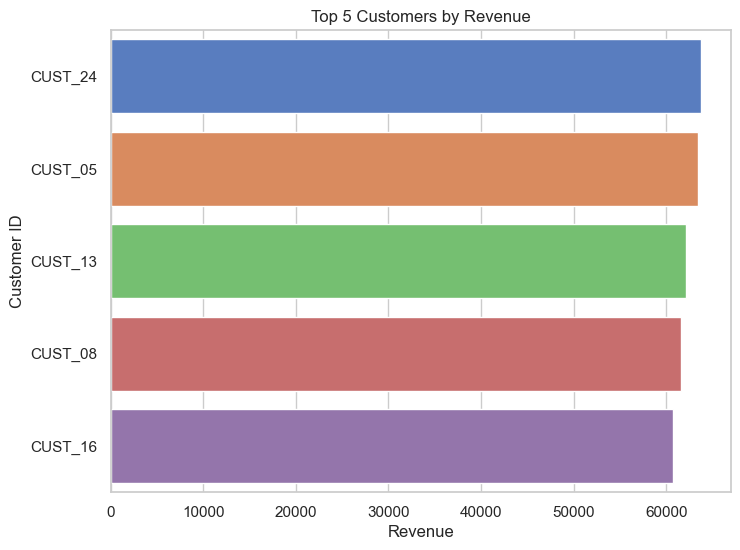

In [78]:
top_customers = df.groupby('Customer ID')['Total Spent'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette='muted')
plt.title('Top 5 Customers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Customer ID')
plt.show()


Revenue per Month

/Users/madinayelmuratova/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


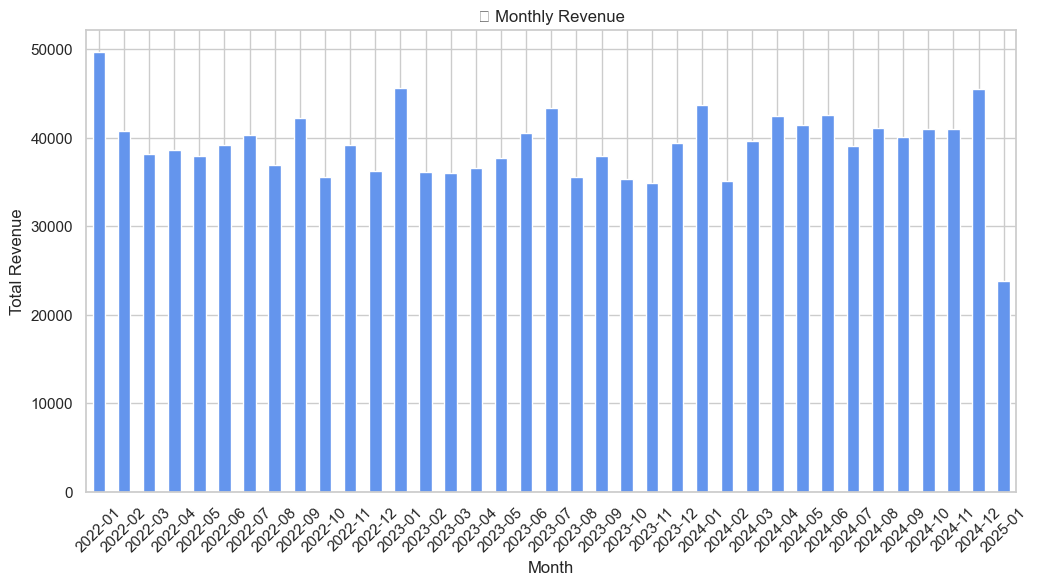

In [79]:
# Преобразуем дату в период
df['Month'] = df['Transaction Date'].dt.to_period('M')

# Выручка по месяцам
monthly_revenue = df.groupby('Month')['Total Spent'].sum()

# Построение
plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='bar', color='cornflowerblue')
plt.title('🛒 Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


 Revenue per Location

/var/folders/z8/pc06963d4072jjyq_y3w06980000gn/T/ipykernel_6414/2019313916.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=location_sales.index, x=location_sales.values, palette='mako')


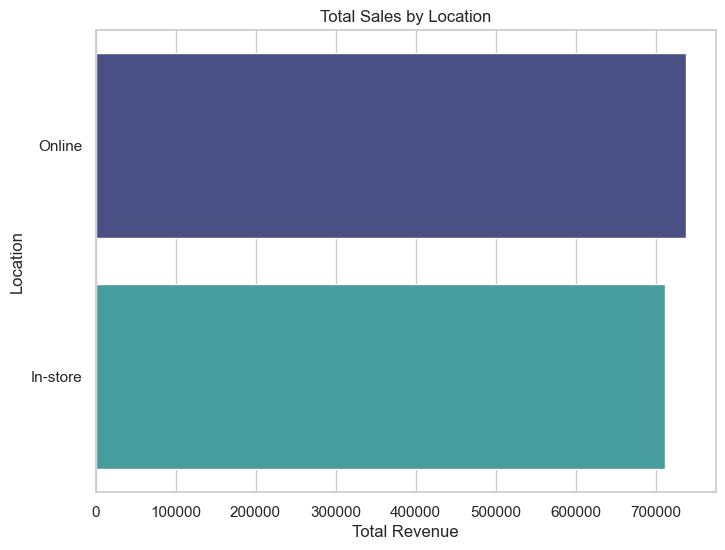

In [43]:
location_sales = df.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(y=location_sales.index, x=location_sales.values, palette='mako')
plt.title('Total Sales by Location')
plt.xlabel('Total Revenue')
plt.ylabel('Location')
plt.show()

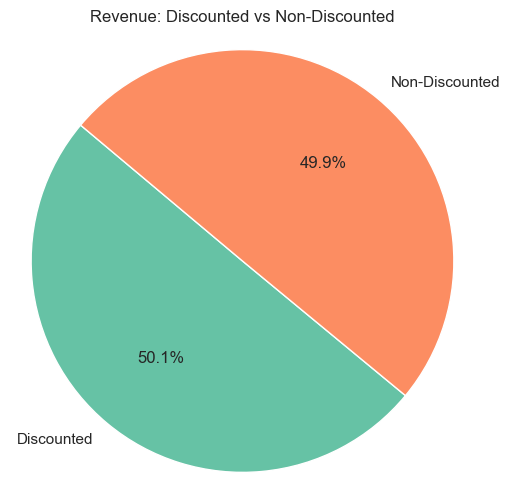

In [83]:
# Считаем выручку по наличию скидки
discounted_revenue = df[df['Discount Applied'] == True]['Total Spent'].sum()
non_discounted_revenue = df[df['Discount Applied'] == False]['Total Spent'].sum()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    [discounted_revenue, non_discounted_revenue],
    labels=['Discounted', 'Non-Discounted'],
    autopct='%1.1f%%',
    colors=['#66c2a5','#fc8d62'],
    startangle=140
)
plt.title('Revenue: Discounted vs Non-Discounted')
plt.axis('equal')
plt.show()


The revenue split between discounted and non-discounted transactions is almost equal, with 50.1% of sales involving discounts and 49.9% occurring without them.
This suggests that while discount strategies are impactful, the store also maintains strong sales performance without relying solely on promotions

In [85]:
# Средний чек со скидкой
discounted_aov = df[df['Discount Applied'] == True]['Total Spent'].mean()

# Средний чек без скидки
non_discounted_aov = df[df['Discount Applied'] == False]['Total Spent'].mean()

print(f" Average Order Value (Discounted): ${discounted_aov:.2f}")
print(f" Average Order Value (Non-Discounted): ${non_discounted_aov:.2f}")


 Average Order Value (Discounted): $129.10
 Average Order Value (Non-Discounted): $129.01


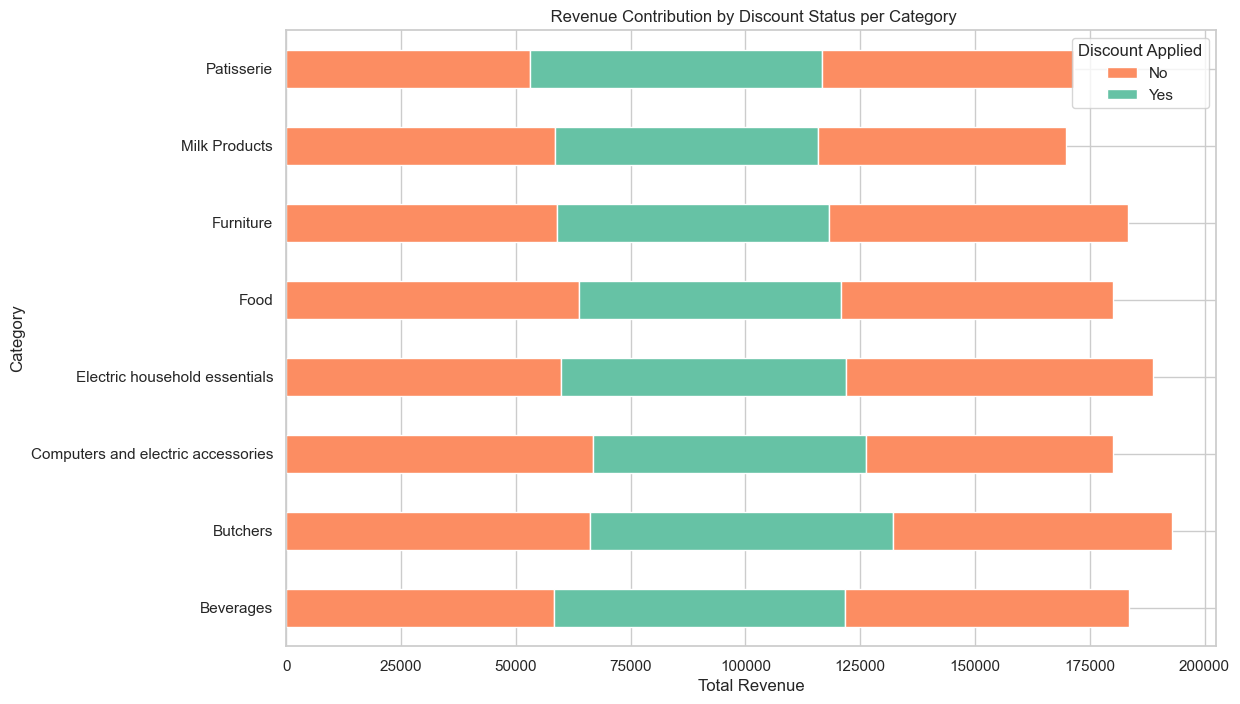

In [89]:
#Group revenue by Category and Discount Status
category_discount_revenue = df.groupby(['Category', 'Discount Applied'])['Total Spent'].sum().unstack(fill_value=0)

# Строим stacked bar plot
category_discount_revenue.plot(
    kind='barh',
    stacked=True,
    figsize=(12,8),
    color=['#fc8d62', '#66c2a5']  # Non-Discounted, Discounted
)
plt.title(' Revenue Contribution by Discount Status per Category')
plt.xlabel('Total Revenue')
plt.ylabel('Category')
plt.legend(title='Discount Applied', labels=['No', 'Yes'])
plt.grid(True)
plt.show()


The majority of revenue across categories was generated from non-discounted transactions.
Discounted sales contributed a smaller, supplemental share in most categories, indicating that while discounting is used strategically, the business does not rely heavily on it to drive sales

Clustering

In [90]:
import pandas as pd
from datetime import timedelta

# 1. Убедимся, что даты в правильном формате
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

# 2. Определяем snapshot date (например, день после последней покупки в данных)
snapshot_date = df['Transaction Date'].max() + timedelta(days=1)

# 3. Строим RFM таблицу
rfm = df.groupby('Customer ID').agg({
    'Transaction Date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Transaction ID': 'nunique',                                   # Frequency
    'Total Spent': 'sum'                                           # Monetary
})

# 4. Переименуем столбцы
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 5. Смотрим результат
rfm.reset_index(inplace=True)
rfm.head()


,Customer ID,Recency,Frequency,Monetary
0,CUST_01,1,458,54678.0
1,CUST_02,3,444,58282.5
2,CUST_03,4,420,55920.0
3,CUST_04,1,426,57139.0
4,CUST_05,5,496,63445.5


In [91]:
from sklearn.preprocessing import StandardScaler

# Масштабируем только числовые RFM-показатели
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Посмотрим форму данных
print(rfm_scaled.shape)



(25, 3)


In [92]:
from sklearn.cluster import KMeans

# Инициализируем модель
kmeans = KMeans(n_clusters=3, random_state=42)

# Обучаем модель
kmeans.fit(rfm_scaled)

# Добавляем кластеры в RFM-таблицу
rfm['Cluster'] = kmeans.labels_

# Смотрим результат
rfm.head()


/Users/madinayelmuratova/opt/anaconda3/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,Customer ID,Recency,Frequency,Monetary,Cluster
0,CUST_01,1,458,54678.0,1
1,CUST_02,3,444,58282.5,1
2,CUST_03,4,420,55920.0,2
3,CUST_04,1,426,57139.0,1
4,CUST_05,5,496,63445.5,0


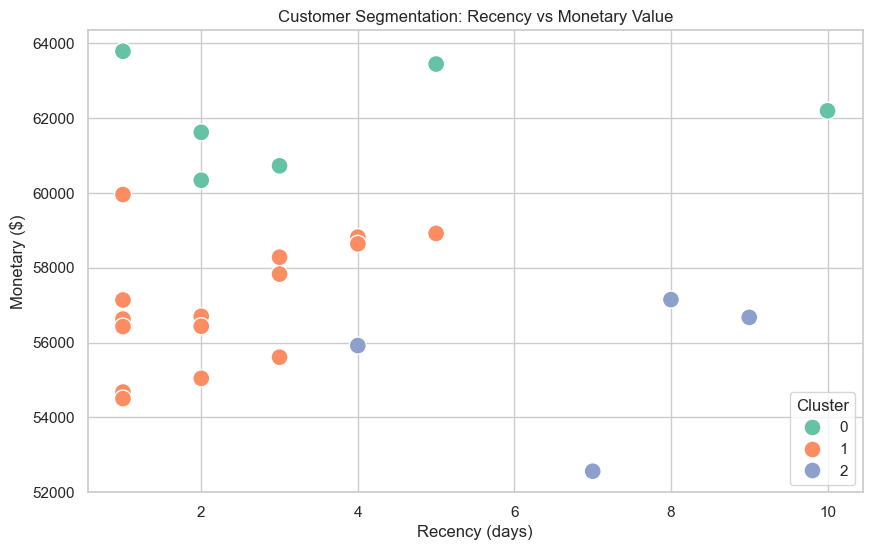

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=150
)
plt.title('Customer Segmentation: Recency vs Monetary Value')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary ($)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()


Кластер 1 (оранжевый): Это клиенты с высокой частотой покупок и средней суммой трат. Их стоит поощрять скидками или специальными предложениями для удержания.

Кластер 2 (синий): Эти клиенты показывают меньшую активность (больше дней с последней покупки), но тратили значительную сумму, что говорит о потенциале для возвращения.

Кластер 0 (зелёный): Клиенты, которые активно покупают и тратят большие суммы. Это самые ценные и лояльные клиенты, которых стоит поддерживать высококачественным обслуживанием.

In [ ]:
ML

In [ ]:
Data prep(Random Forest Analysis)

In [102]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Фичи и целевая переменная
X = rfm[['Recency', 'Frequency']]
y = rfm['Monetary']

# Деление на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Модель Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Предсказания
y_pred_rf = rf.predict(X_test)


In [ ]:
MAE, RMSE, R²

In [103]:
# Метрики модели
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MAE: {mae_rf:.2f}")
print(f"Random Forest - RMSE: {rmse_rf:.2f}")
print(f"Random Forest - R² Score: {r2_rf:.2f}")


Random Forest - MAE: 2830.91
Random Forest - RMSE: 3171.10
Random Forest - R² Score: 0.30


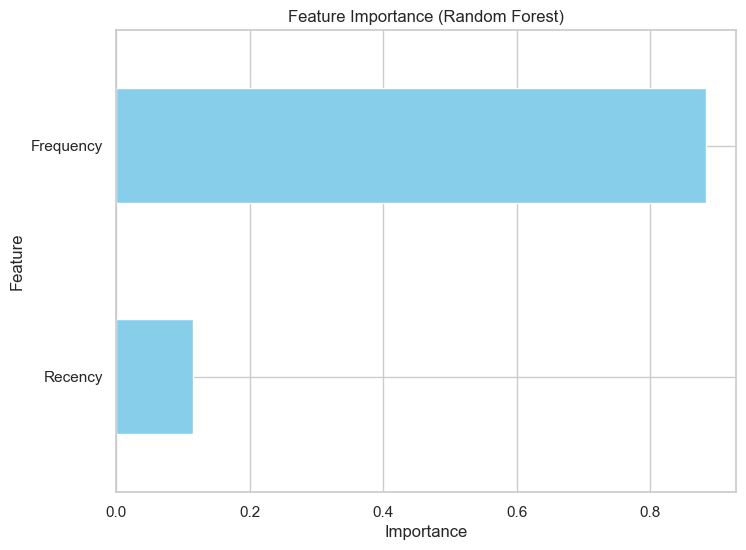

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Важность признаков
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)

# Построение графика важности признаков
plt.figure(figsize=(8,6))
feature_importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True)
plt.show()


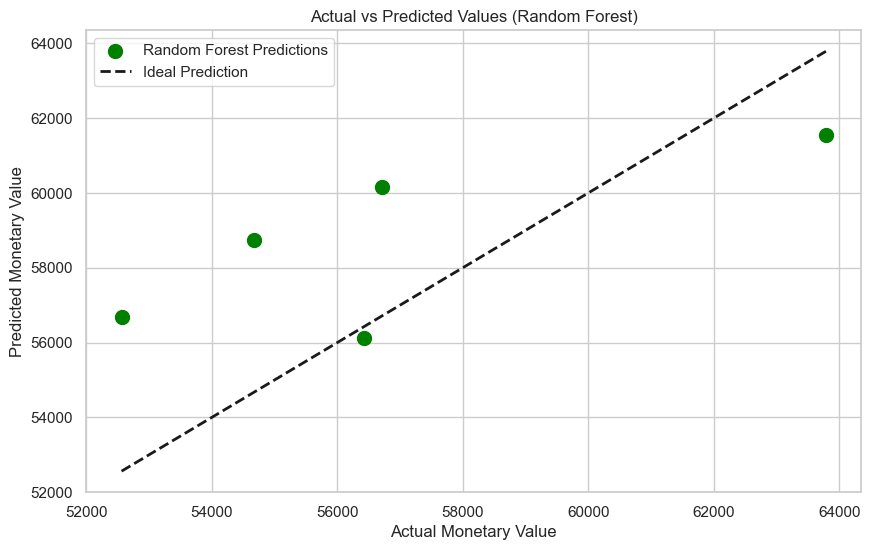

In [105]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_rf, color='green', s=100, label='Random Forest Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Prediction')
plt.xlabel('Actual Monetary Value')
plt.ylabel('Predicted Monetary Value')
plt.title('Actual vs Predicted Values (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()


In [106]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Фичи и целевая переменная
X = rfm[['Recency', 'Frequency']]
y = rfm['Monetary']

# Деление на обучающую и тестовую выборку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Модель Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Предсказания
y_pred_lr = lr.predict(X_test)


In [107]:
# Метрики модели
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - MAE: {mae_lr:.2f}")
print(f"Linear Regression - RMSE: {rmse_lr:.2f}")
print(f"Linear Regression - R² Score: {r2_lr:.2f}")


Linear Regression - MAE: 2539.62
Linear Regression - RMSE: 2705.46
Linear Regression - R² Score: 0.49


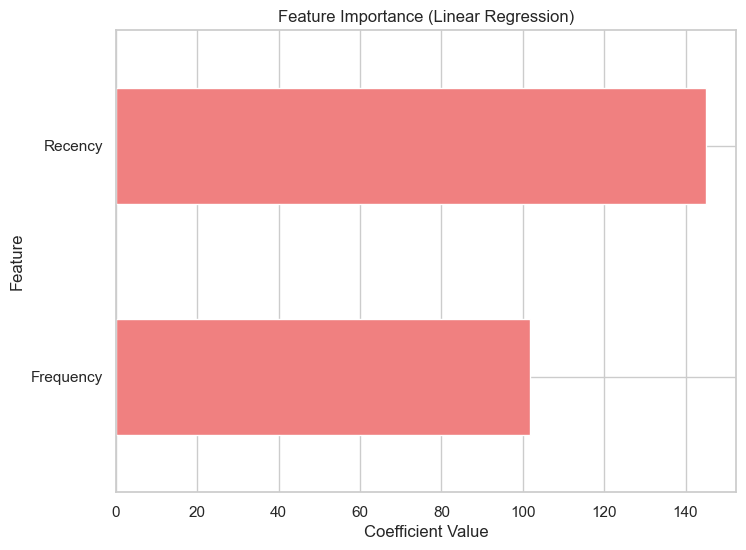

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

# Коэффициенты модели
coef = pd.Series(lr.coef_, index=X.columns)

# Построение графика коэффициентов
plt.figure(figsize=(8,6))
coef.sort_values().plot(kind='barh', color='lightcoral')
plt.title('Feature Importance (Linear Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(True)
plt.show()


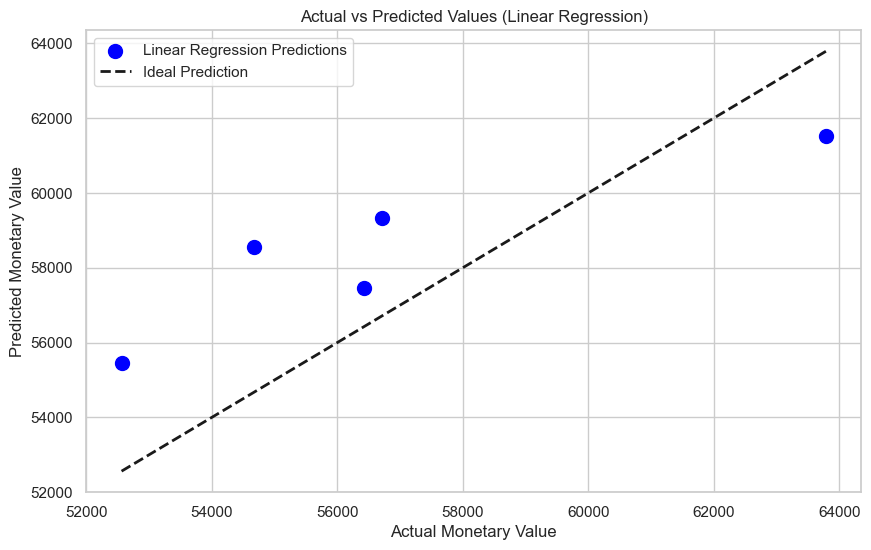

In [110]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_lr, color='blue', s=100, label='Linear Regression Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Prediction')
plt.xlabel('Actual Monetary Value')
plt.ylabel('Predicted Monetary Value')
plt.title('Actual vs Predicted Values (Linear Regression)')
plt.legend()
plt.grid(True)
plt.show()


By using machine learning models to predict customer monetary value based on behavioral patterns (Recency and Frequency), we provide the business with actionable insights that enable more targeted loyalty programs, retention strategies, and revenue optimization planning

Frequency was found to be the most important feature.Investing in customers with high Frequency and recent activity could yield the highest returns

-- Ключевые выводы
Финансовые показатели:

Общая выручка за анализируемый период составила 1 450 038,50 долларов США.

Средний чек (AOV) стабильно находился на ур
При возможности расширить датасет дополнительными поведенческими признаками (например, история просмотров, возвраты товаров).

In [ ]:
-- Ключевые выводы
Финансовые показатели:

- Общая выручка за анализируемый период составила 1 450 038,50 долларов США.

- Средний чек (AOV) стабильно находился на уровне ~128 долларов, независимо от применения скидок.

- Примерно 50% всех продаж приходилось на заказы со скидкой, что подчёркивает важность промо-стратегий.

Поведение клиентов:

- Средний размер корзины составил 5,5 товара за один заказ.

- Средний интервал между покупками — 2,46 дня, что говорит о высокой вовлеченности покупателей.

- На выходные дни приходился наибольший объём продаж.

Кластеризация клиентов:

Кластерный анализ выявил три ключевые группы клиентов:

- Кластер 0: Высокоценные лояльные клиенты (VIP) — совершают частые и крупные покупки.

- Кластер 1: Активные клиенты со средним уровнем расходов — регулярные покупатели.

- Кластер 2: Клиенты с высоким риском потери — ранее активные, но их активность снизилась.

- Частота покупок (Frequency) оказалась самым важным фактором, влияющим на сумму расходов клиента.

Анализ машинного обучения:

- Линейная регрессия показала лучшие результаты в прогнозировании расходов клиентов (R² = 0,49), по сравнению с моделью Random Forest.

- Простые модели обеспечивают лучшее обобщение при небольшом объёме данных и линейных взаимосвязях признаков.

-- Бизнес-рекомендации
Работа с VIP-клиентами (Кластер 0):

- Внедрить эксклюзивные программы лояльности: персональные скидки, доступ к новым товарам до официальных запусков.

- Развивать персонализированное обслуживание для усиления привязанности клиентов.

- Поддержание активности клиентов (Кластер 1):

- Разработать бонусные программы для частых покупателей (например, скидки или подарки за определенное количество заказов).

Реактивация клиентов с высоким риском (Кластер 2):

Запустить кампании повторного привлечения: специальные скидки для "вернувшихся" клиентов, персонализированные предложения.

Оптимизация стратегии скидок:

Продолжать использовать скидки для увеличения объёма продаж, но контролировать их влияние на маржинальность.

Предлагать скидки в категориях с высокой чувствительностью к цене.

Увеличение частоты покупок:

Запускать программы подписки, реферальные программы или мотивационные акции для увеличения частоты покупок.

Развитие аналитики:

При возможности расширить датасет дополнительными поведенческими признаками (например, история просмотров, возвраты товаров).